In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [4]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


In [5]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


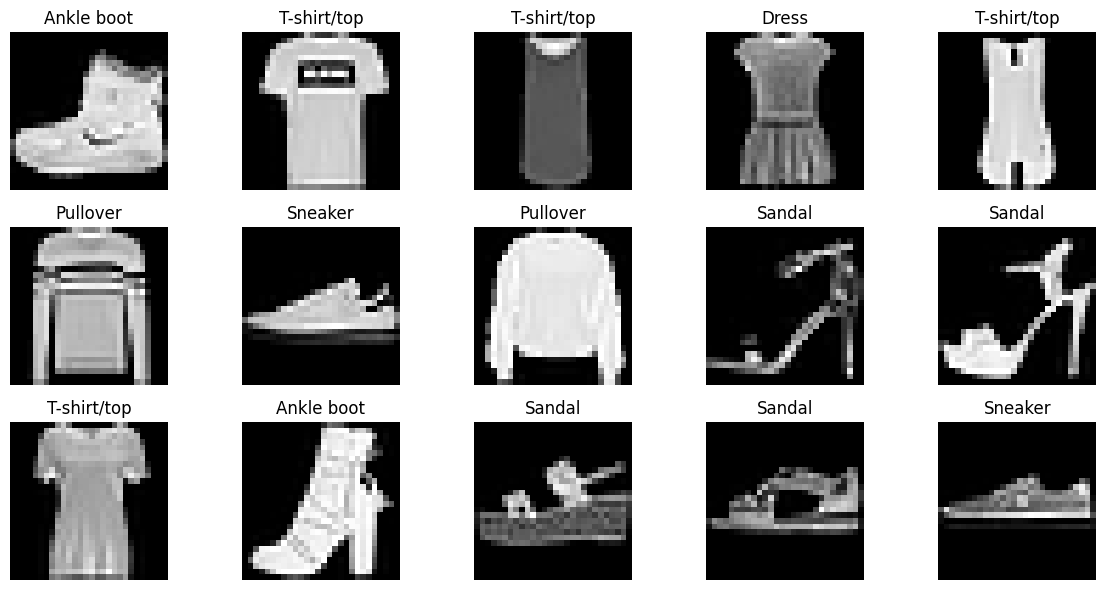

In [6]:
plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
unique, counts = np.unique(y_train, return_counts=True)

class_distribution = pd.DataFrame({
    "Class": [class_names[i] for i in unique],
    "Count": counts
})

print(class_distribution)

         Class  Count
0  T-shirt/top   6000
1      Trouser   6000
2     Pullover   6000
3        Dress   6000
4         Coat   6000
5       Sandal   6000
6        Shirt   6000
7      Sneaker   6000
8          Bag   6000
9   Ankle boot   6000


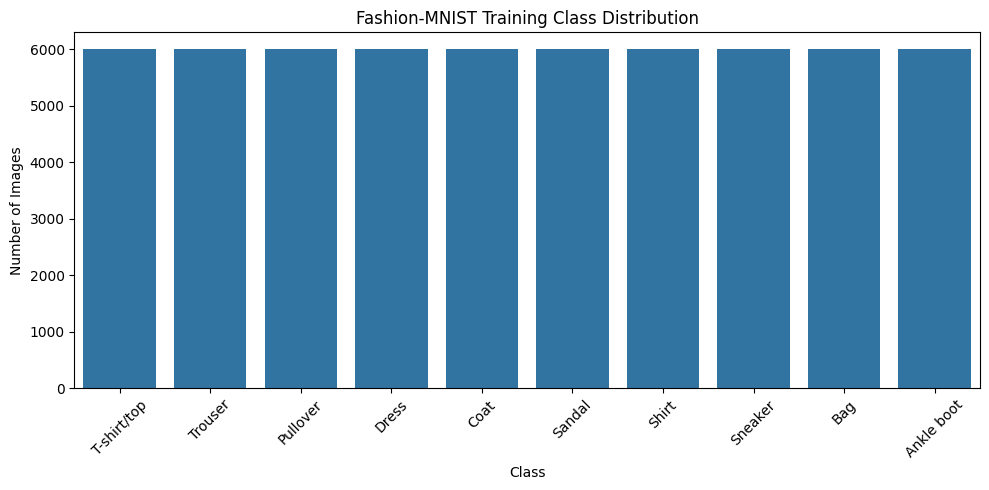

In [8]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=class_distribution,
    x="Class",
    y="Count"
)

plt.xticks(rotation=45)
plt.title("Fashion-MNIST Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [9]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [11]:
model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(128, activation="relu"),
    Dropout(0.30),

    Dense(64, activation="relu"),
    Dropout(0.20),

    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [13]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4930 - loss: 1.4116 - val_accuracy: 0.7006 - val_loss: 0.8895
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6845 - loss: 0.8554 - val_accuracy: 0.7557 - val_loss: 0.6799
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7319 - loss: 0.7202 - val_accuracy: 0.7726 - val_loss: 0.6060
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7584 - loss: 0.6509 - val_accuracy: 0.7871 - val_loss: 0.5645
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7772 - loss: 0.6061 - val_accuracy: 0.7969 - val_loss: 0.5324
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7886 - loss: 0.5740 - val_accuracy: 0.8113 - val_loss: 0.5107
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7993 - loss: 0.5489 - val_accuracy: 0.8197 - val_loss: 0.4898
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8093 - loss: 0.5247 - val_accuracy: 

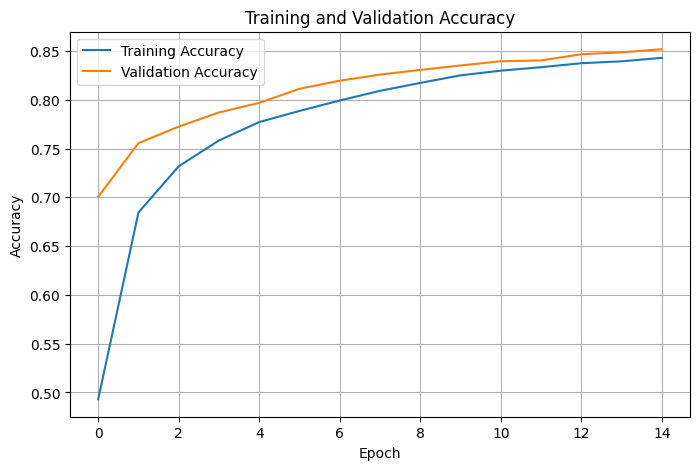

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

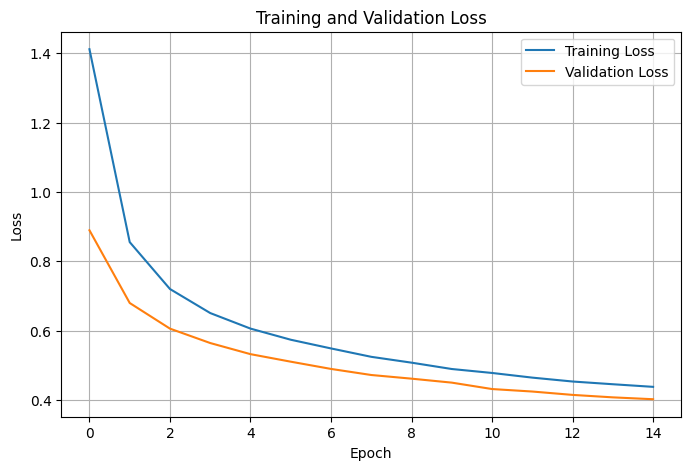

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.4290299415588379
Test Accuracy: 0.8450999855995178


In [18]:
y_probability = model.predict(X_test)

y_pred = np.argmax(y_probability, axis=1)

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predictions generated successfully.


In [19]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 84.51%


In [20]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.81      0.80      1000
     Trouser       0.98      0.95      0.97      1000
    Pullover       0.71      0.81      0.76      1000
       Dress       0.81      0.89      0.85      1000
        Coat       0.76      0.74      0.75      1000
      Sandal       0.94      0.91      0.92      1000
       Shirt       0.67      0.53      0.59      1000
     Sneaker       0.90      0.92      0.91      1000
         Bag       0.95      0.96      0.96      1000
  Ankle boot       0.92      0.94      0.93      1000

    accuracy                           0.85     10000
   macro avg       0.84      0.85      0.84     10000
weighted avg       0.84      0.85      0.84     10000



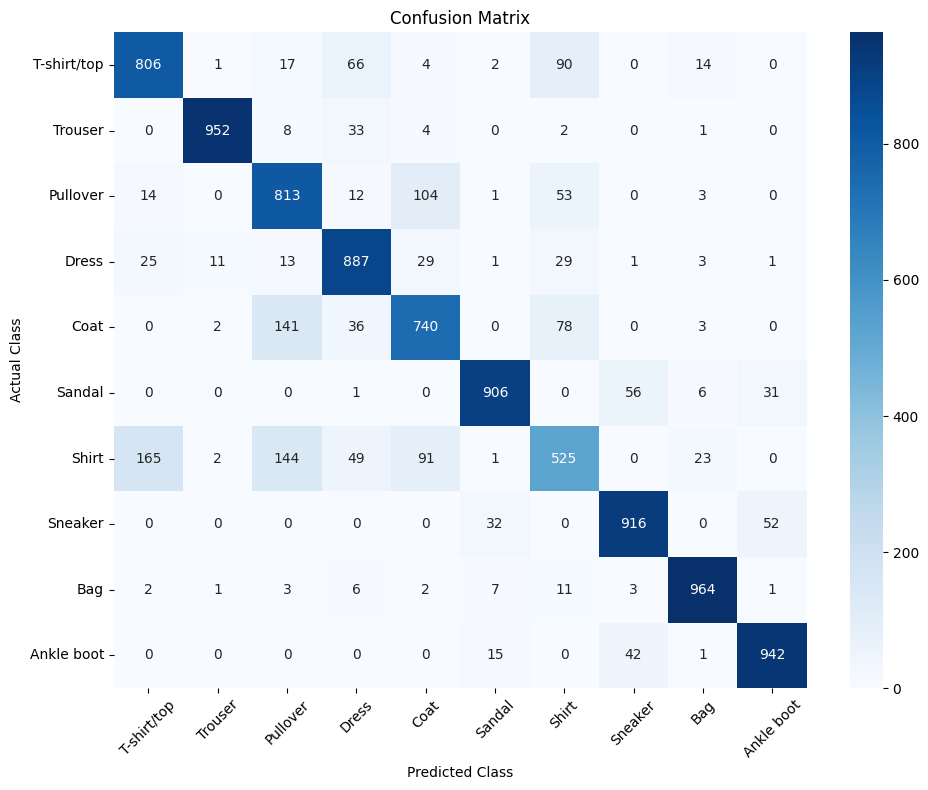

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

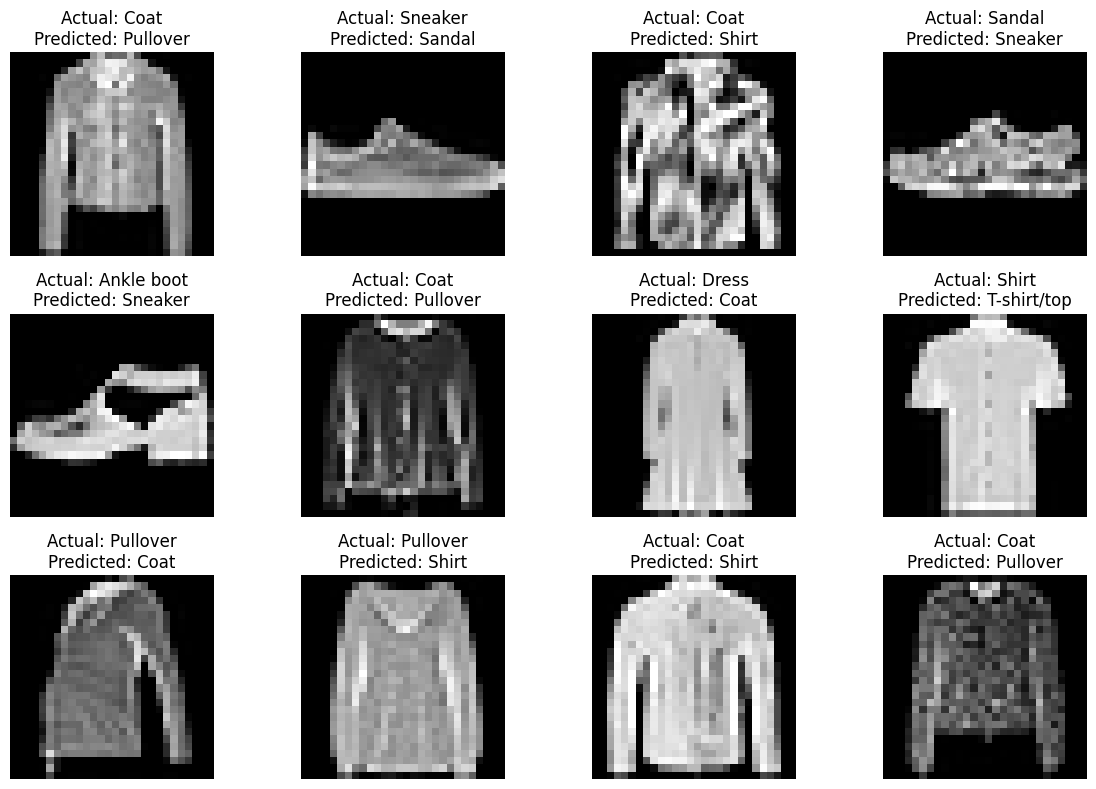

In [22]:
plt.figure(figsize=(12, 8))

incorrect_indices = np.where(y_pred != y_test)[0]

for i, index in enumerate(incorrect_indices[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[index], cmap="gray")
    plt.title(
        f"Actual: {class_names[y_test[index]]}\n"
        f"Predicted: {class_names[y_pred[index]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

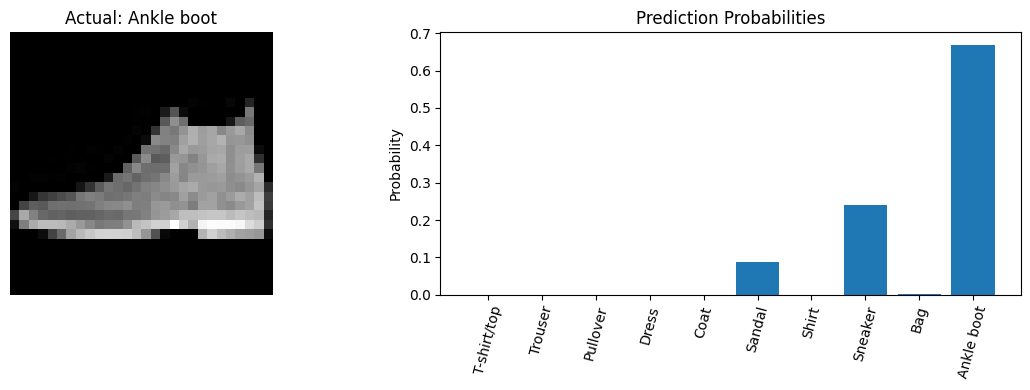

In [23]:
sample_index = 0

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(X_test[sample_index], cmap="gray")
plt.title(f"Actual: {class_names[y_test[sample_index]]}")
plt.axis("off")

plt.subplot(1, 2, 2)

plt.bar(
    class_names,
    y_probability[sample_index]
)

plt.xticks(rotation=75)
plt.ylabel("Probability")
plt.title("Prediction Probabilities")

plt.tight_layout()
plt.show()

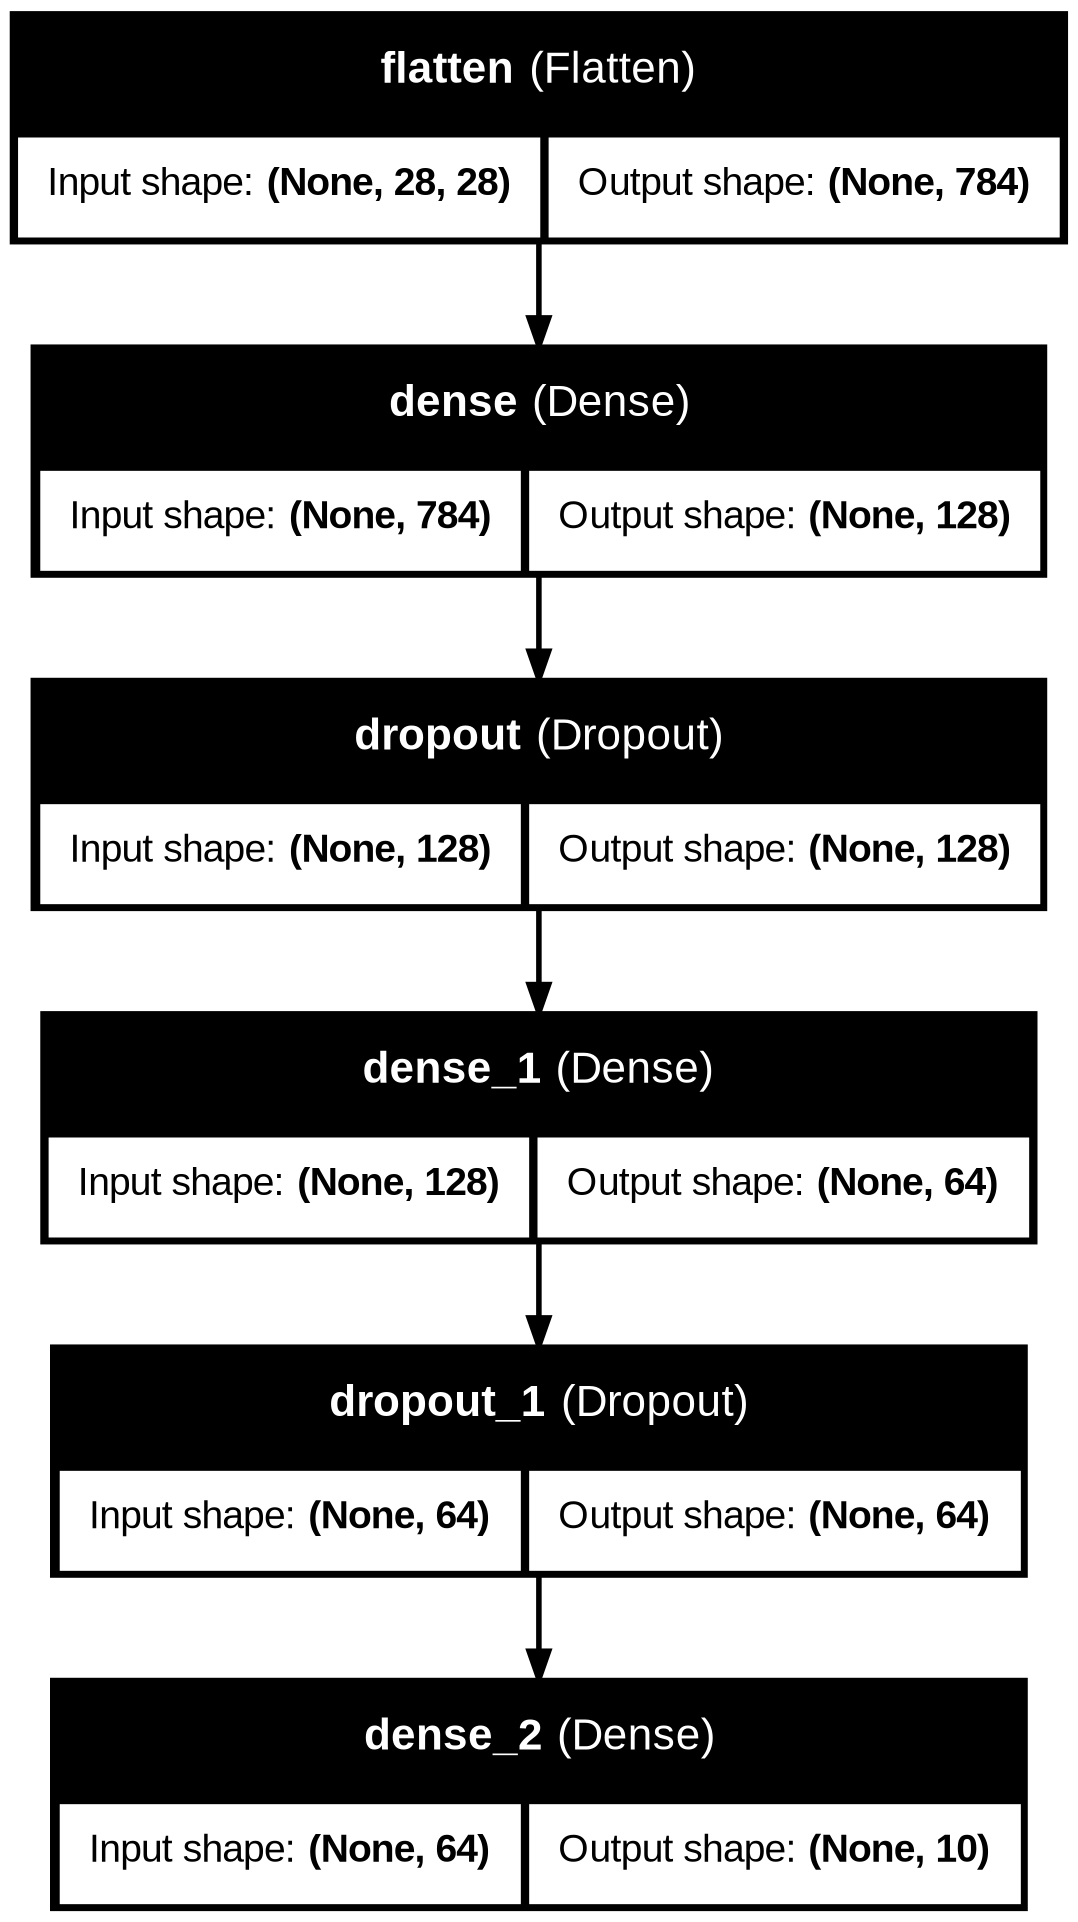

In [24]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="fashion_mnist_model_architecture.png",
    show_shapes=True,
    show_layer_names=True
)

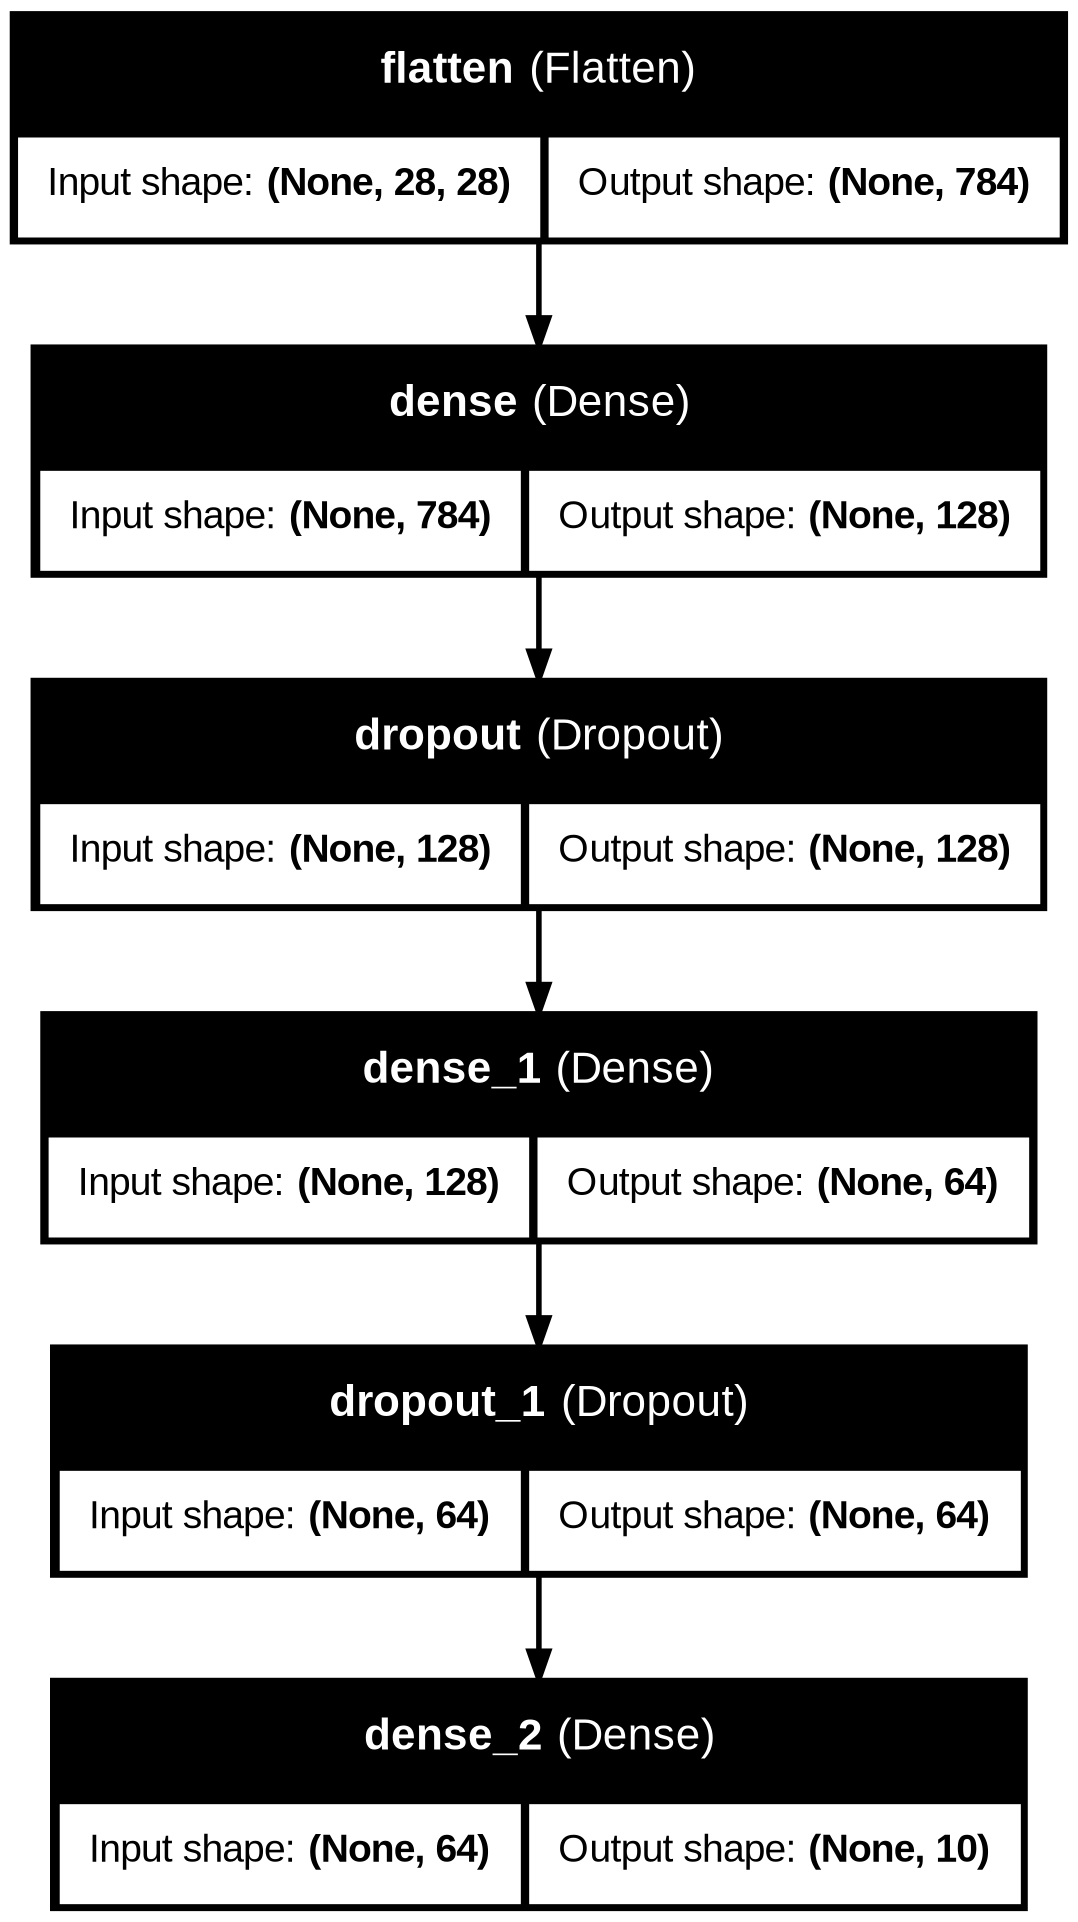

In [25]:
from IPython.display import Image, display

display(Image(filename="fashion_mnist_model_architecture.png"))

In [26]:
model.save("fashion_mnist_deep_learning_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [27]:
predictions_df = pd.DataFrame({
    "Actual_Label": y_test,
    "Predicted_Label": y_pred,
    "Actual_Class": [class_names[i] for i in y_test],
    "Predicted_Class": [class_names[i] for i in y_pred]
})

predictions_df.to_csv(
    "fashion_mnist_predictions.csv",
    index=False
)

print("Prediction file created.")

Prediction file created.


In [28]:
predictions_df = pd.DataFrame({
    "Actual_Label": y_test,
    "Predicted_Label": y_pred,
    "Actual_Class": [class_names[i] for i in y_test],
    "Predicted_Class": [class_names[i] for i in y_pred]
})

predictions_df.to_csv(
    "fashion_mnist_predictions.csv",
    index=False
)

print("Prediction file created.")

Prediction file created.


In [29]:
from google.colab import files

files.download("fashion_mnist_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
print("=" * 50)
print("WEEK 5 DEEP LEARNING PROJECT SUMMARY")
print("=" * 50)

print("Dataset: Fashion-MNIST")
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Number of Classes:", len(class_names))
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print("=" * 50)

WEEK 5 DEEP LEARNING PROJECT SUMMARY
Dataset: Fashion-MNIST
Training Samples: 60000
Testing Samples: 10000
Number of Classes: 10
Test Accuracy: 84.51%
Test Loss: 0.4290
